In [1]:
import os
import matplotlib.pyplot as plt
import torch
import numpy as np
from tqdm import tqdm
from loaddataset import loadDataset
from net import Net
from loss_function import *
from torch_geometric.data import Data
from torch_geometric.nn import radius_graph
from constant import *
from torch_scatter import scatter
from torch_geometric.nn import radius_graph
from matplotlib import pyplot as plt

In [2]:
import warnings
warnings.filterwarnings("ignore")

depolar_model_dict_path = "../model_pt/2024_1_6_18_51_53.pth"
depolar_model = Net(num_features=128,
                    act='swish',
                    maxl=3,
                    num_block=3,
                    num_radial=32,
                    attention_head=8,
                    rc=5.0,
                    max_atomic_number=35,
                    scalar_outsize=2,
                    irreps_out='2e',
                    summation=True,
                    out_type='2_tensor',
                    grad_type='polar',
                    device='cpu')
depolar_model.load_state_dict(state_dict=torch.load(depolar_model_dict_path, map_location=torch.device('cpu')))

<All keys matched successfully>

In [3]:
Hi_model_dict_path = "../model_pt/2024_1_6_18_45_39.pth"
Hi_model = Net(num_features=128,
               act='swish',
               maxl=3,
               num_block=3,
               num_radial=32,
               attention_head=8,
               rc=5.0,
               max_atomic_number=35,
               scalar_outsize=1,
               irreps_out=None,
               summation=False,
               out_type='scalar',
               grad_type='Hi',
               device='cpu')
Hi_model.load_state_dict(state_dict=torch.load(Hi_model_dict_path, map_location=torch.device('cpu')))

<All keys matched successfully>

In [4]:
Hij_model_dict_path = "../model_pt/2024_1_6_18_44_49.pth"
Hij_model = Net(num_features=128,
                act='swish',
                maxl=3,
                num_block=3,
                num_radial=32,
                attention_head=8,
                rc=5.0,
                max_atomic_number=35,
                scalar_outsize=1,
                irreps_out=None,
                summation=False,
                out_type='scalar',
                grad_type='Hij',
                device='cpu')
Hij_model.load_state_dict(state_dict=torch.load(Hij_model_dict_path, map_location=torch.device('cpu')))

<All keys matched successfully>

In [14]:

def hessfreq(Hi,Hij,edge_index,masses,normal=False,linear=False,scale=0.965):
    '''Combine the Hessian matrices of the Hi and Hij parts and calculate the frequencies and normal coordinates

    normal:Whether or not to normalize the normal coordinates,Default: False

    linear:Is it a linear molecule? Default: False

    scale:Correction factor for frequency.Default:0.965

    It is worth mentioning that the output frequency may generate NaN in the first frequency,
    which corresponds to the negative frequency in quantum chemistry calculations, Simply delete this frequency.
    '''

    #Calculating the masses matrix
    wmasses=torch.pow(masses.to(Hi.device),-0.5).repeat_interleave(3, dim=0)
    wmat=wmasses[:,None]*wmasses[None,:]

    #Construction of hessian matrix by atomic part and interatomic part
    i, j = edge_index
    dia=torch.arange(0,len(Hi),step=1,device=Hi.device,dtype=int)
    hessian=torch.zeros(size=(Hi.shape[0],3,Hi.shape[0],3),device=Hi.device)
    hessian[j,:,i,:]=Hij
    hessian[dia,:,dia,:]=Hi
    hessian=hessian.reshape(Hi.shape[0]*3,Hi.shape[0]*3)

    #predicted hesssian matrix (ij part) may be asymmetric,we take the average of two directions to make it symmetric
    hessian=(hessian+hessian.permute(1,0))/2


    hessian=hessian*wmat

    #Diagonalisation
    eva, evec=torch.linalg.eigh(hessian)
    eva = eva * hess_t
    freq=torch.pow(eva,0.5)/ (2 * torch.pi)
    freq=freq/cm_hz
    p=-evec.t()*wmasses
    normals = torch.norm(p, dim=1).unsqueeze(1)
    if normal:
        p=p/normals
    p=p.reshape(len(freq),-1,3)
    if scale is not None:
        freq=freq*scale
    if linear:
        return freq[5:],p[5:]
    else:
        return freq[6:],p[6:]


def chain_rule_raman(dp,modes):
    '''Calculation of raman tensor by the chain rule
    The input polarizability derivatives unit are 'a0**3/A',
    '''
    ramans=(modes[...,None]*dp[None,:,:,:]).reshape(modes.shape[0],-1,6)
    raman_tensor=torch.sum(ramans,dim=1)
    return raman_tensor

def get_raman_act(raman_tensor):
    '''Calculation of Raman activity from the Raman tensor
    calculate by 45x(alpha**2)+7x(gamma**2)  alpha and gamma represent isotropic and anisotropic part of Raman tensor
    The output Raman activity is in units of A**4/Amu(Consistent with gaussian g16)
    '''
    xx=raman_tensor[:,0]
    xy=raman_tensor[:,1]
    yy=raman_tensor[:,2]
    xz=raman_tensor[:,3]
    zy=raman_tensor[:,4]
    zz=raman_tensor[:,5]
    alpha=(xx+yy+zz)/3
    gamma_sq1=0.5*(((xx-yy)**2)+((yy-zz)**2)+((zz-xx)**2))
    gamma_sq2=3*((xy**2)+(xz**2)+(zy**2))
    gamma_sq=gamma_sq1+gamma_sq2
    return (45*(alpha**2)+7*gamma_sq)*raman_coff

def get_raman_intensity(freq,raman_act,temp=298,init_wl=532):
    '''Raman intensity is calculated from the Raman activity and frequency,temperature and incident light Wavelength.
     The output Raman intensity is unitless.
     Unfortunately, 32-float is not sufficient for Raman calculations and only 64-float can be used to calculate Raman
     '''
    init_freq_si=cm_hz/ (init_wl * 1e-7)
    freq_si=freq.to(torch.float64)*cm_hz
    act_si=raman_act.to(torch.float64)*(A_m**4)/45
    last=1/(1-torch.exp(-hp*c*freq_si/(Kb*temp)))
    dv=((init_freq_si-freq_si)**4)/freq_si
    return act_si*dv*last

class nn_vib_analysis(torch.nn.Module):
    '''Complete with IR and Raman simulations by coordinates and atomic types.
    Simulations can be carried out in batches.

    Unfortunately, the shape of a hessian matrix is [num_atom*3,num_atom*3]
    pytorch does not support turning hessian into a batch.
    We therefore used an iterative algorithm for diagonalising and calculating IR and Raman,
    with a small improvement in simulation time.
    But it is still fast, taking about 0.5s (gpu) and 1s (cpu) to simulate 1 molecule.
     simulate a batch of 16 molecules takes roughly 1s(gpu) and 4s(cpu)
    '''
    def __init__(self,device0='cpu',device1='cpu',device2='cpu',Linear=False,scale=0.965):
        super(nn_vib_analysis,self).__init__()
        '''Linear:whether it is a linear molecule (linear molecule e.g. hydrocyanic acid and butadiene), 
        if it is linear then [3*num_atom-5] frequencies and intensities will be calculated instead of [3*num_atom-6]
        
        scale:correction factor, quantum chemistry calculations usually overestimated frequencies 
        and need to be corrected by a correction factor, the default is 0.965 
        (i.e. the correction factor of the reference data B3LYP/TZVP used for training)
        
        device:There are two options torch.device('cpu') and torch.device('cuda'), 
        representing the use of cpu or gpu for computation respectively
        
        '''

        self.device0=device0
        self.device1=device1
        self.device2=device2
        self.linear=Linear
        self.scale=scale
        self.model_dp=depolar_model.to(device0)
        self.model_Hi=Hi_model.to(device1)
        self.model_Hij=Hij_model.to(device2)
        # self.model_dd=dedipole_model(device=device)
        
    def bondsbatch2atomsbatch(self,atoms_count,atoms_x):
        atoms_batch = torch.zeros(size=[atoms_x.shape[0]],dtype=torch.int64)
        strat_x = 0
        for i in range(atoms_count.shape[0]):
            atoms_batch[strat_x : strat_x + atoms_count[i][0]] = i
            strat_x += atoms_count[i][0]
        return atoms_batch

    def forward(self,batch):
        
        torch.cuda.empty_cache()
        
        atoms_batch = self.bondsbatch2atomsbatch(batch.atoms_count,
                                            batch.atoms_x)
        edge_index=radius_graph(x=batch.atoms_pos,r=5.0,batch=atoms_batch)
        Hi= self.model_Hi(atoms_x = batch.atoms_x.to(self.device1), 
                    atoms_pos = batch.atoms_pos.to(self.device1), 
                    atoms_edge_index = edge_index.to(self.device1),   
                    atoms_batch = atoms_batch.to(self.device1),
                    bonds_x = batch.x.to(self.device1),    
                    bonds_edge_index=batch.edge_index.to(self.device1), 
                    bonds_edge_attr=batch.edge_attr.to(self.device1),    
                    bonds_batch=batch.batch.to(self.device1))
        Hij= self.model_Hij(atoms_x = batch.atoms_x.to(self.device2), 
                    atoms_pos = batch.atoms_pos.to(self.device2), 
                    atoms_edge_index = edge_index.to(self.device2),   
                    atoms_batch = atoms_batch.to(self.device2),
                    bonds_x = batch.x.to(self.device2),    
                    bonds_edge_index=batch.edge_index.to(self.device2), 
                    bonds_edge_attr=batch.edge_attr.to(self.device2),    
                    bonds_batch=batch.batch.to(self.device2))
        # dd= self.model_dd(pos=pos,z=z,batch=batch)
        dp= self.model_dp(atoms_x = batch.atoms_x.to(self.device0), 
                    atoms_pos = batch.atoms_pos.to(self.device0), 
                    atoms_edge_index = edge_index.to(self.device0),   
                    atoms_batch = atoms_batch.to(self.device0),
                    bonds_x = batch.x.to(self.device0),    
                    bonds_edge_index=batch.edge_index.to(self.device0), 
                    bonds_edge_attr=batch.edge_attr.to(self.device0),    
                    bonds_batch=batch.batch.to(self.device0))
        return Hi.cpu(),Hij.cpu(),dp.cpu(),edge_index,atoms_batch
    
def calspec(Hi,Hij,dp,edge_index,batch,atoms_x,idx):
        vib_list = []
        atom_num=0
        atoms_x_idx_min = torch.min(torch.argwhere(batch==idx))
        atoms_x_idx_max = torch.max(torch.argwhere(batch==idx))
        bat_edge_index_mid = edge_index[:,edge_index[1]>=atoms_x_idx_min]
        Hij_m = Hij[edge_index[1]>=atoms_x_idx_min]
        Hij_m = Hij_m[bat_edge_index_mid[1]<=atoms_x_idx_max]
        bat_edge_index_mid = bat_edge_index_mid[:,bat_edge_index_mid[1]<=atoms_x_idx_max]
        # print("Hi,Hij.shape",Hi.shape,Hij.shape,batch.shape)
        freq,modes = freq, modes = hessfreq(Hi=Hi[batch==idx], Hij=Hij_m,
                                       masses=atom_masses[atoms_x[batch==idx]], edge_index=bat_edge_index_mid-bat_edge_index_mid.min(),
                                       normal=False)
        raman_act = get_raman_act(chain_rule_raman(dp=dp[batch==idx], modes=modes))
        # vib_list.append([freq, raman_act])
        return freq,raman_act


def Lorenz_broadening(x0, y0,c=torch.linspace(500, 4000, 3501), sigma=12):
    '''Lorenz broadening for Vibration and NMR spectroscopies
    x0 y0:Position of the horizontal and vertical axes to be broadening

    c:Position of the broadening horizontal axis and number of points

    sigma:spread half width

    The position of the vertical axis after the output has been broadened.
    '''
    lx= x0[:,None]-c[None,:]
    ly= (sigma/(2*3.1415926))/(lx**2 + 0.25*(sigma**2))
    y= torch.sum(y0[:,None]*ly,dim=0)
    return y.view(-1)
def freqaraman2spec(freq,araman):
    x_axis=torch.linspace(500, 4000, 3501)
    yraman_act=Lorenz_broadening(freq,araman,c=x_axis,sigma=12)
    #get raman intensity from raman act,frequency
    yraman=get_raman_intensity(x_axis,yraman_act).detach().numpy()
    x=x_axis.detach().numpy()
    return x_axis,yraman

print('load utils done!')

load utils done!


In [15]:
from function import np2data

'''
The spectrum calculation modules of DetaNet consists of a tensor of the shape [Num_atom,3] 
indicating the position of the atom and a LongTensor of [Num_atom] indicating the element type.
Here, we take the example of Phenol
'''
pos=torch.tensor([[ 9.7233e-02,  1.3689e+00,  1.3115e-01],
        [ 6.7777e-02,  3.2910e-03,  3.8910e-02],
        [ 7.6066e-02, -6.6728e-01, -1.1832e+00],
        [ 4.4743e-02, -2.0582e+00, -1.2085e+00],
        [ 5.2200e-03, -2.7850e+00, -2.4071e-02],
        [-2.7410e-03, -2.1055e+00,  1.1924e+00],
        [ 2.8234e-02, -7.1819e-01,  1.2309e+00],
        [ 1.2295e-01,  1.7542e+00, -7.5192e-01],
        [ 1.0686e-01, -1.0483e-01, -2.1109e+00],
        [ 5.1425e-02, -2.5716e+00, -2.1622e+00],
        [-1.9064e-02, -3.8668e+00, -4.6867e-02],
        [-3.3378e-02, -2.6606e+00,  2.1220e+00],
        [ 2.2412e-02, -1.7973e-01,  2.1697e+00]],device='cpu',dtype=torch.float32)

z=torch.LongTensor([8, 6, 6, 6, 6, 6, 6, 1, 1, 1, 1, 1, 1])

data = np2data(z, pos, 'test')

In [16]:
from torch_geometric.loader import DataLoader
datasetloader = DataLoader([data],1,False)

vib_model=nn_vib_analysis(device0='cpu',device1='cpu',device2='cpu',Linear=False,scale=1)
data_t = datasetloader
yraman_pred_all = np.zeros(shape=[len(data_t.dataset),3501])
yraman_label_all = np.zeros(shape=[len(data_t.dataset),3501])
name = []
strat_idx = 0
for batch in tqdm(data_t):
    Hi,Hij,dp,edge_index,atoms_batch =vib_model(batch)
    for idx in range(batch.batch[-1]+1):      
        freq_pred,araman_pred = calspec(Hi,Hij,dp,edge_index,atoms_batch,batch.atoms_x,idx)
        x_axis_pred,yraman_pred = freqaraman2spec(freq_pred,araman_pred)
        yraman_pred_all[strat_idx,:] = yraman_pred
        name.append(batch["name"][idx])
        strat_idx += 1

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:03<00:00,  3.10s/it]


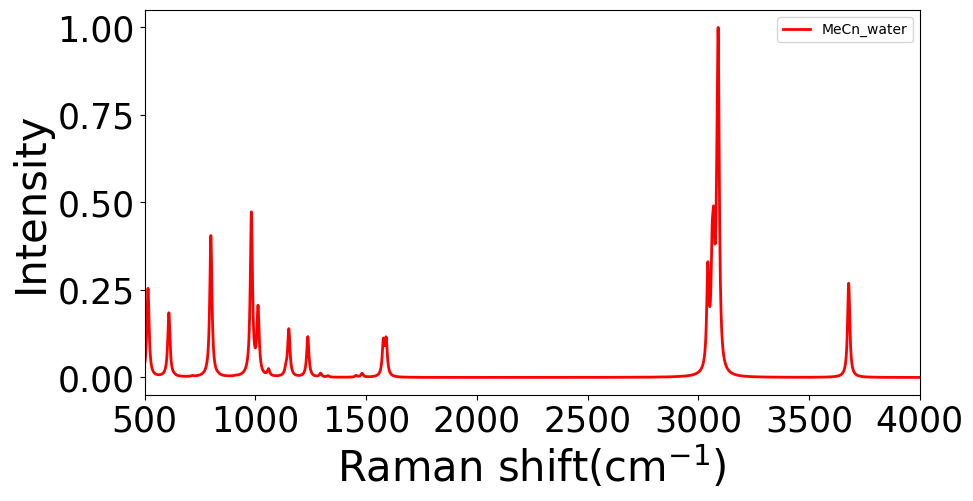

In [17]:

idx1 = 0
plt.figure(figsize=(10,5))
plt.xlim(500,4000)
x_axis = torch.linspace(500, 4000, 3501)
plt.plot(x_axis,yraman_pred_all[idx1]/yraman_pred_all[idx1].max(),lw=2,label='MeCn_water',color='red')
plt.xlabel('Raman shift(cm$^{-1}$)',fontsize='30')
#设置Y轴标签
plt.tick_params(axis='x', which='major', labelsize=25) 
plt.ylabel('Intensity',fontsize='30')
plt.tick_params(axis='y', which='major', labelsize=25) 
plt.legend(fontsize=10)
plt.show()